# Aridity Index & Budyko Curve Script

## Purpose
This script extracts the mean aridity index for each groundwater monitoring
site from a global climate raster and plots a Budyko curve to visualize
how groundwater trends relate to climate water balance.

---

## Inputs
| File | Description |
|------|-------------|
| `gwl_cult_et_1km.csv` | Site locations with site_id, latitude, longitude |
| `ai_v31_yr.tif` | Global Aridity Index raster (Zomer et al. 2022) |
| `site_summary_1km.csv` | Site summary with ET, precipitation, and GW trend -> **THIS WILL CHANGE** |

---

## How to Run for a Different Bounding Box
Only the marked lines under `── Use Functions ──` need to change:

```python
# Step 1 — Extract aridity
aridity_1km = extract_aridity(   # CHANGE HERE — variable name 
    bbox_km=1,                   # CHANGE HERE — bounding box size 
    area_label="1km",            # CHANGE HERE — label 
    sites_csv=SITES_CSV,
    aridity_tif=ARIDITY_TIF
)

# Step 2 — Plot Budyko curve
plot_budyko(
    summary_csv=SUMMARY_CSV,
    aridity_df=aridity_1km,      # CHANGE HERE — match variable from Step 1
    ai_col="AI_1km",             # CHANGE HERE — match area_label 
)
```

> **Rule:** `bbox_km`, `area_label`, `ai_col`, and the **variable name must all match**.


- **Example: For A Different BBOX**: `bbox_km=16`, `area_label="16km"`, `ai_col="AI_16km"`, `aridity_16km`

---

## Outputs
| Output | Description |
|--------|-------------|
| `sites_aridity_{area_label}.csv` | CSV with AI and aridity_class columns added per site |

---

## Functions
**`extract_aridity(bbox_km, area_label, sites_csv, aridity_tif)`**
Extracts mean aridity index for each site within the bounding box and
classifies each site as arid (AI < 0.6) or humid (AI ≥ 0.6).

**`plot_budyko(summary_csv, aridity_df, ai_col)`**
Merges aridity data with site summary, runs a validation check, and
plots the Budyko curve with groundwater trend as the color gradient.

---

## Validation Check
Before plotting, the script automatically checks:
- No null values in AI, dryness index, ET:Precip, or GW trend
- AI values are within expected range (0–1.5)
- Dryness index and ET:Precip are positive

If any check fails, an error will be raised before the plot is generated.

---

## Notes
- Raw raster values are divided by 10,000 to get actual AI values

- Aridity threshold: 
    - AI < 0.6 = `arid`, 
    - AI ≥ 0.6 = `humid`

- Dryness Index is computed as `1 / AI` for the Budyko x-axis

- Log scale is applied to the x-axis to spread clustered arid sites

In [1]:
# Libraries
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

# Function for Aridity Index and Budyko Curve

Extracting AI_1km for 50 sites (1km box)
Saved: /capstone/aridgw/outputs/1km/sites_aridity_1km.csv
--- Validation: AI_1km ---
Total sites: 50
ET:Precip     — min: 0.547, max: 6.540, nulls: 0
Dryness Index — min: 0.986, max: 23.585, nulls: 0
AI_1km      — min: 0.042, max: 1.014, nulls: 0
GW Trend      — min: -0.077, max: 2.330, nulls: 0


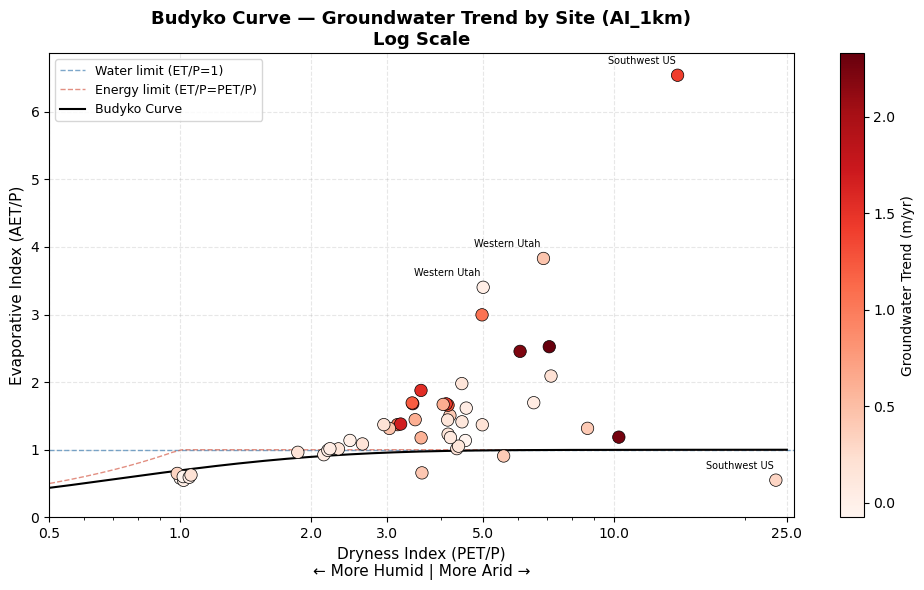

In [ ]:
# --- Load in Paths ---
SITES_CSV    = "/capstone/aridgw/outputs/1km/gwl_cult_et_1km.csv" # CHANGE HERE

ARIDITY_TIF  = "/capstone/aridgw/raw_data/Global_Aridity_Index/Global-AI_ET0__annual_v3_1/ai_v31_yr.tif"

SUMMARY_CSV  = "/capstone/aridgw/outputs/1km/site_summary_1km.csv"  # CHANGE HERE — summary CSV path

AI_SCALE     = 10_000.0  # raw raster values are AI * 10000
AI_THRESHOLD = 0.6       # < 0.6 = arid, >= 0.6 = humid


# ── Convert bounding box size from km to degrees for raster extraction ──────────────────

def km_to_deg(km: float, latitude: float) -> tuple[float, float]:
    """Convert km offset to degrees lat/lon at a given latitude."""
    lat_deg = km / 111.0
    lon_deg = km / (111.0 * np.cos(np.radians(latitude)))
    return lat_deg, lon_deg


# ── Aridity Extraction ────────────────────────────────────────────────────────

def _extract_mean_aridity(src: rasterio.DatasetReader, lat: float, lon: float, bbox_km: float) -> float:
    """Extract mean aridity index within bbox_km around a single point."""
    half = bbox_km / 2
    lat_off, lon_off = km_to_deg(half, lat)

    window = from_bounds(
        left=lon - lon_off,
        bottom=lat - lat_off,
        right=lon + lon_off,
        top=lat + lat_off,
        transform=src.transform
    )
    data = src.read(1, window=window).astype(float)
    data[data == 0] = np.nan

    if np.all(np.isnan(data)):
        return np.nan

    return float(np.nanmean(data)) / AI_SCALE


def extract_aridity(bbox_km: float, area_label: str, sites_csv: str, aridity_tif: str) -> pd.DataFrame:
    """
    Extract mean aridity index for each site within a bounding box.

    Parameters:
        bbox_km     : side length of bounding box in km (e.g. 1, 5, 10, 16)
        area_label  : label for output column and file (e.g. '1km', '16km') # CHANGE HERE
        sites_csv   : path to input CSV with site_id, latitude, longitude
        aridity_tif : path to Global Aridity Index raster
    """

    ai_col     = f"AI_{area_label}"
    output_csv = f"/capstone/aridgw/outputs/{area_label}/sites_aridity_{area_label}.csv"

    # Reading in CSV
    df    = pd.read_csv(sites_csv)
    sites = df[["site_id", "latitude", "longitude"]].drop_duplicates().copy()

    print(f"Extracting {ai_col} for {len(sites)} sites ({bbox_km}km box)")

    with rasterio.open(aridity_tif) as src:
        sites[ai_col] = sites.apply(
            lambda row: _extract_mean_aridity(src, row["latitude"], row["longitude"], bbox_km),
            axis=1
        )

    result = df.merge(sites[["site_id", ai_col]], on="site_id", how="left")
    result["aridity_class"] = np.where(result[ai_col] < AI_THRESHOLD, "arid", "humid")

    # EXPORTS to CSV
    result.to_csv(output_csv, index=False)

    # Shows filepath in print statment
    print(f"Saved: {output_csv}")

    return result


# ── Budyko Plot ───────────────────────────────────────────────────────────────

def plot_budyko(summary_csv: str, aridity_df: pd.DataFrame, ai_col: str):
    """
    Plot Budyko curve with groundwater trend color gradient.

    Parameters:
        summary_csv : path to site_summary CSV (ET, precip, gw_trend)
        aridity_df  : DataFrame returned from extract_aridity()  # CHANGE HERE — pass variable from Step 1
        ai_col      : aridity index column name (e.g. 'AI_1km', 'AI_16km')  # CHANGE HERE
    """

    # Load and merge
    df = pd.read_csv(summary_csv)
    ai = aridity_df[["site_id", ai_col]].drop_duplicates()  # uses DataFrame directly
    df = df.merge(ai, on="site_id", how="left")


    # Dryness Index (PET/P) — inverse of Aridity Index for Budyko x-axis
    df["dryness_index"] = 1 / df[ai_col]


    # ── Validation Check ──────────────────────────────────────────────────────
    print(f"--- Validation: {ai_col} ---") # This will update with CSV
    print(f"Total sites: {len(df)}")
    print(f"ET:Precip     — min: {df['et_precip_ratio'].min():.3f}, max: {df['et_precip_ratio'].max():.3f}, nulls: {df['et_precip_ratio'].isna().sum()}")
    print(f"Dryness Index — min: {df['dryness_index'].min():.3f}, max: {df['dryness_index'].max():.3f}, nulls: {df['dryness_index'].isna().sum()}")
    print(f"{ai_col}      — min: {df[ai_col].min():.3f}, max: {df[ai_col].max():.3f}, nulls: {df[ai_col].isna().sum()}")
    print(f"GW Trend      — min: {df['gw_trend_m_per_yr'].min():.3f}, max: {df['gw_trend_m_per_yr'].max():.3f}, nulls: {df['gw_trend_m_per_yr'].isna().sum()}")

    assert df[ai_col].between(0, 1.5).all(), f"{ai_col} values out of expected range"
    assert df["dryness_index"].gt(0).all(), "Dryness index has zero or negative values"
    assert df["et_precip_ratio"].gt(0).all(), "ET:Precip ratio has zero or negative values"


    # ── Plot ──────────────────────────────────────────────────────────────────
    di_curve = np.linspace(0.01, 25, 500)
    budyko_y = np.sqrt((1 - np.exp(-di_curve)) * di_curve * np.tanh(1 / di_curve))

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.axhline(y=1, color="steelblue", linestyle="--", linewidth=1, alpha=0.7, label="Water limit (ET/P=1)")
    ax.plot(di_curve, np.minimum(di_curve, 1), color="#d6604d", linestyle="--", linewidth=1, alpha=0.7, label="Energy limit (ET/P=PET/P)")
    ax.plot(di_curve, budyko_y, color="black", linewidth=1.5, label="Budyko Curve", zorder=2)

    sc = ax.scatter(
        df["dryness_index"], df["et_precip_ratio"],
        c=df["gw_trend_m_per_yr"], cmap=plt.cm.Reds,
        vmin=df["gw_trend_m_per_yr"].min(), vmax=df["gw_trend_m_per_yr"].max(),
        s=80, edgecolors="black", linewidths=0.5, zorder=4
    )

    plt.colorbar(sc, ax=ax, label="Groundwater Trend (m/yr)")

    outliers = df[(df["et_precip_ratio"] > 3.0) | (df["dryness_index"] > 15)]
    for _, row in outliers.iterrows():
        ax.annotate(row["region"],
                    xy=(row["dryness_index"], row["et_precip_ratio"]),
                    xytext=(-50, 8), textcoords="offset points",
                    fontsize=7, color="black")

    ax.set_xscale("log")
    ax.set_xlim(0.5, df["dryness_index"].max() * 1.1)
    ax.set_xticks([0.5, 1, 2, 3, 5, 10, 25])
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

    ax.set_ylim(0, df["et_precip_ratio"].max() * 1.05)
    ax.set_xlabel("Dryness Index (PET/P)\n← More Humid | More Arid →", fontsize=11)
    ax.set_ylabel("Evaporative Index (AET/P)", fontsize=11)
    ax.set_title(f"Budyko Curve — Groundwater Trend by Site ({ai_col})\nLog Scale", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()


# ── Use Functions ────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    # Step 1 — Extract aridity
    aridity_1km = extract_aridity(   # CHANGE HERE: Variable name (ex: aridity_16km)
        
        # Size of Bounding Box
        bbox_km=1,                   # CHANGE HERE

        # Label for bbox
        area_label="1km",            # CHANGE HERE

        sites_csv=SITES_CSV,
        aridity_tif=ARIDITY_TIF

    )

    # Step 2 — Plot Budyko curve
    plot_budyko(
        summary_csv=SUMMARY_CSV,

        # Match variable from Step 1
        aridity_df=aridity_1km,                      # CHANGE HERE

        # Match area_label
        ai_col="AI_1km",                             # CHANGE HERE

    )